# Phase 3: Data Cleaning & Feature Exploration 

This notebook prepares the HR attrition dataset for exploratory analysis and predictive modeling.

In [1]:
import pandas as pd
import numpy as np  

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [6]:
cols_to_drop = [
    'EmployeeCount',
    'Over18',
    'StandardHours',
    'EmployeeNumber'
]

df_clean = df.drop(columns=cols_to_drop)

df_clean.shape

(1470, 31)

In [8]:
df_clean['AttritionFlag'] = df_clean['Attrition'].map({
    'Yes': 1,
    'No': 0
})

df_clean[['Attrition', 'AttritionFlag']].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [9]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print('Numeric columns:', len(numeric_cols))
print(numeric_cols)

print('\nCategorical columns:', len(categorical_cols))
print(categorical_cols)

Numeric columns: 24
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AttritionFlag']

Categorical columns: 8
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [10]:
attrition_corr = (
    df_clean[numeric_cols]
    .corr()['AttritionFlag']
    .sort_values(ascending=False)
)

attrition_corr

AttritionFlag               1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: AttritionFlag, dtype: float64

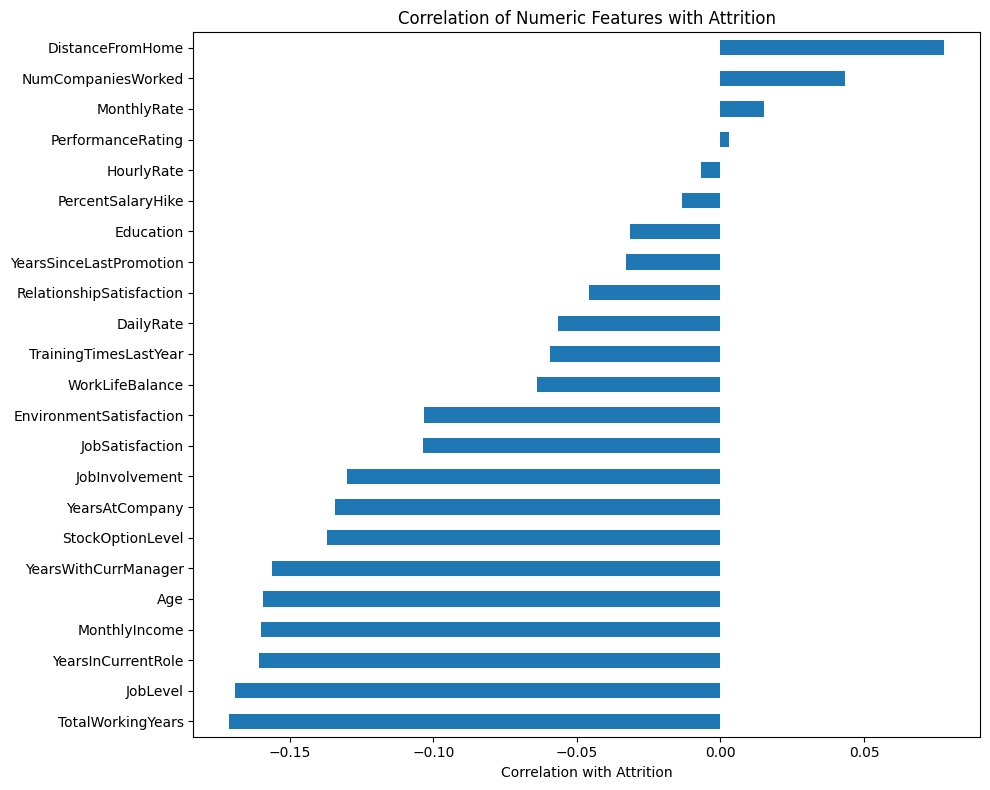

In [11]:
attrition_corr.drop("AttritionFlag").sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)

plt.title("Correlation of Numeric Features with Attrition")
plt.xlabel("Correlation with Attrition")

plt.tight_layout()
plt.show()

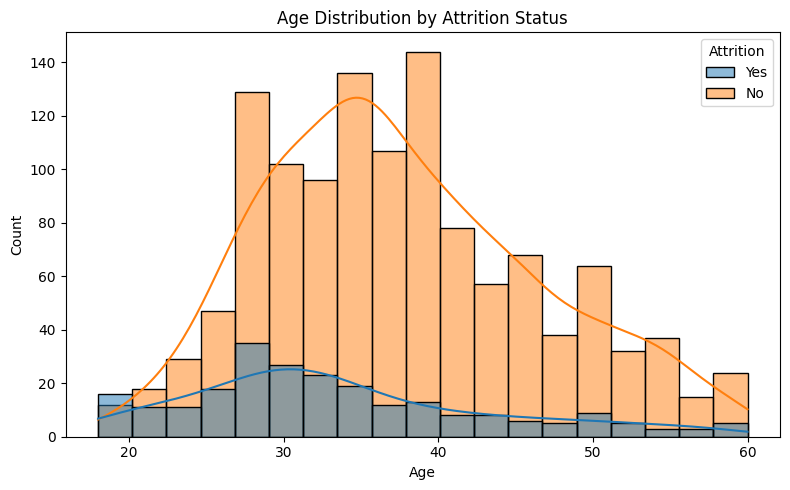

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x='Age',
    hue='Attrition',
    kde=True,
)

plt.title('Age Distribution by Attrition Status')
plt.tight_layout()
plt.show()

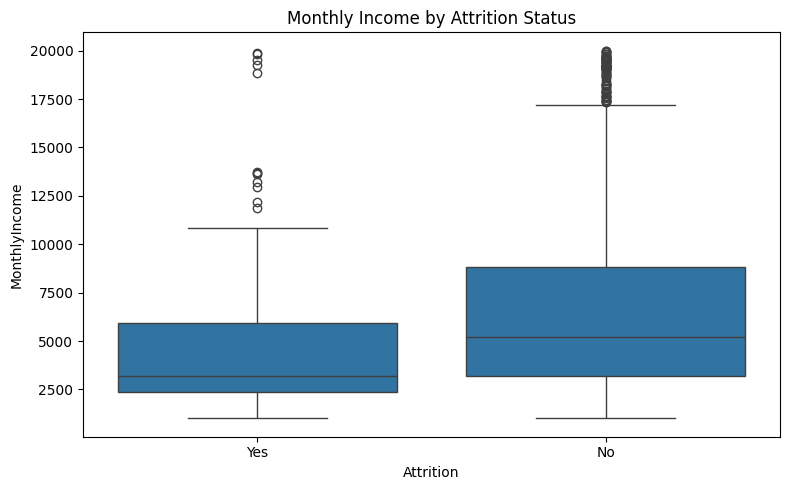

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition Status")
plt.tight_layout()
plt.show()

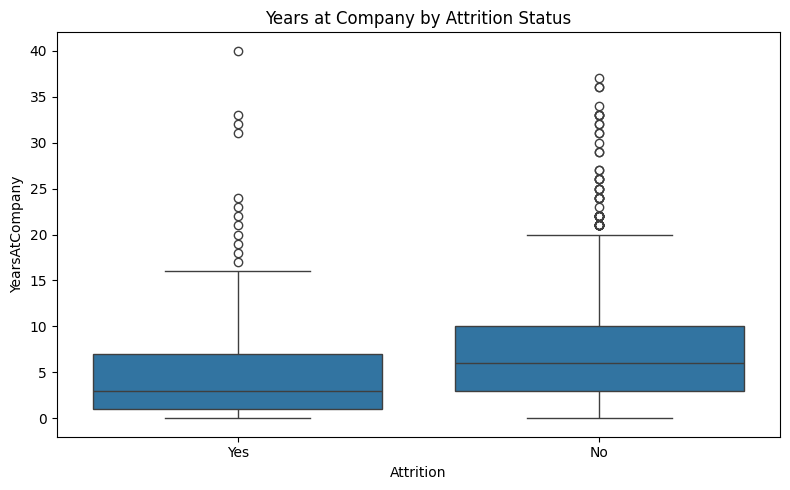

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company by Attrition Status")
plt.tight_layout()
plt.show()

In [15]:
df_clean.to_csv(
    '../data/processed/cleaned_employee_attrition_data.csv', 
    index=False
)

In [16]:
pd.read_csv('../data/processed/cleaned_employee_attrition_data.csv').head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionFlag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0
